# 01-EDA：客户流失数据探索

本笔记本对电信客户流失数据集进行探索性数据分析。

In [2]:
import sys
from pathlib import Path

# 设置路径 - 从 notebooks/ 目录向上两级到项目根
jupyter_notebook_path = Path.cwd()
sys.path.insert(0, str(jupyter_notebook_path.parent))
sys.path.insert(0, str(jupyter_notebook_path.parent.parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from shared.src.data_utils import load_config
from shared.src.viz_utils import plot_corr_heatmap, plot_distribution

# 加载配置
config = load_config(jupyter_notebook_path.parent / "config.yaml")
config

{'project': {'name': '01-customer-churn',
  'version': '0.1.0',
  'random-seed': 42},
 'paths': {'data-dir': './data',
  'outputs-dir': './outputs',
  'mlruns-dir': './mlruns',
  'cache-dir': './.cache'},
 'data': {'dataset-name': 'aai510-group1/telco-customer-churn',
  'target-col': 'Churn',
  'id-col': 'customerID',
  'test-size': 0.2,
  'stratify': True,
  'shuffle': True},
 'preprocessing': {'missing-placeholder': ' ',
  'numeric-like-cols': ['TotalCharges', 'MonthlyCharges', 'tenure'],
  'binary-cols': ['Partner',
   'Dependents',
   'PhoneService',
   'PaperlessBilling',
   'Churn'],
  'multi-category-cols': ['gender',
   'MultipleLines',
   'InternetService',
   'OnlineSecurity',
   'OnlineBackup',
   'DeviceProtection',
   'TechSupport',
   'StreamingTV',
   'StreamingMovies',
   'Contract',
   'PaymentMethod']},
 'features': {'onehot-max-categories': 5, 'scale-numeric': True},
 'model': {'logistic-regression': {'max_iter': 1000,
   'random_state': 42,
   'n_jobs': -1,
   'clas

In [3]:
# 加载原始数据
from src.data_prep import load_data_from_hf

df_raw = load_data_from_hf(config["data"]["dataset-name"])
df_raw.head()

HuggingFace 网络不可达，直接使用 OpenML 数据源


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,'No phone service',DSL,No,Yes,No,No,No,No,Month-to-month,Yes,'Electronic check',29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,'One year',No,'Mailed check',56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,'Mailed check',53.85,108.15,Yes
3,Male,0,No,No,45,No,'No phone service',DSL,Yes,No,Yes,Yes,No,No,'One year',No,'Bank transfer (automatic)',42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,'Fiber optic',No,No,No,No,No,No,Month-to-month,Yes,'Electronic check',70.70,151.65,Yes


In [4]:
# 基础统计信息
df_raw.info()
df_raw.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,Male,NaN,No,No,NaN,Yes,No,'Fiber optic',No,No,No,No,No,No,Month-to-month,Yes,'Electronic check',NaN,' ',No
freq,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [ ]:
# 目标变量分布
df_raw["Churn"].value_counts(normalize=True)
# normalize参数为True时返回相对频率（比例），为False时返回绝对频数（计数）。

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

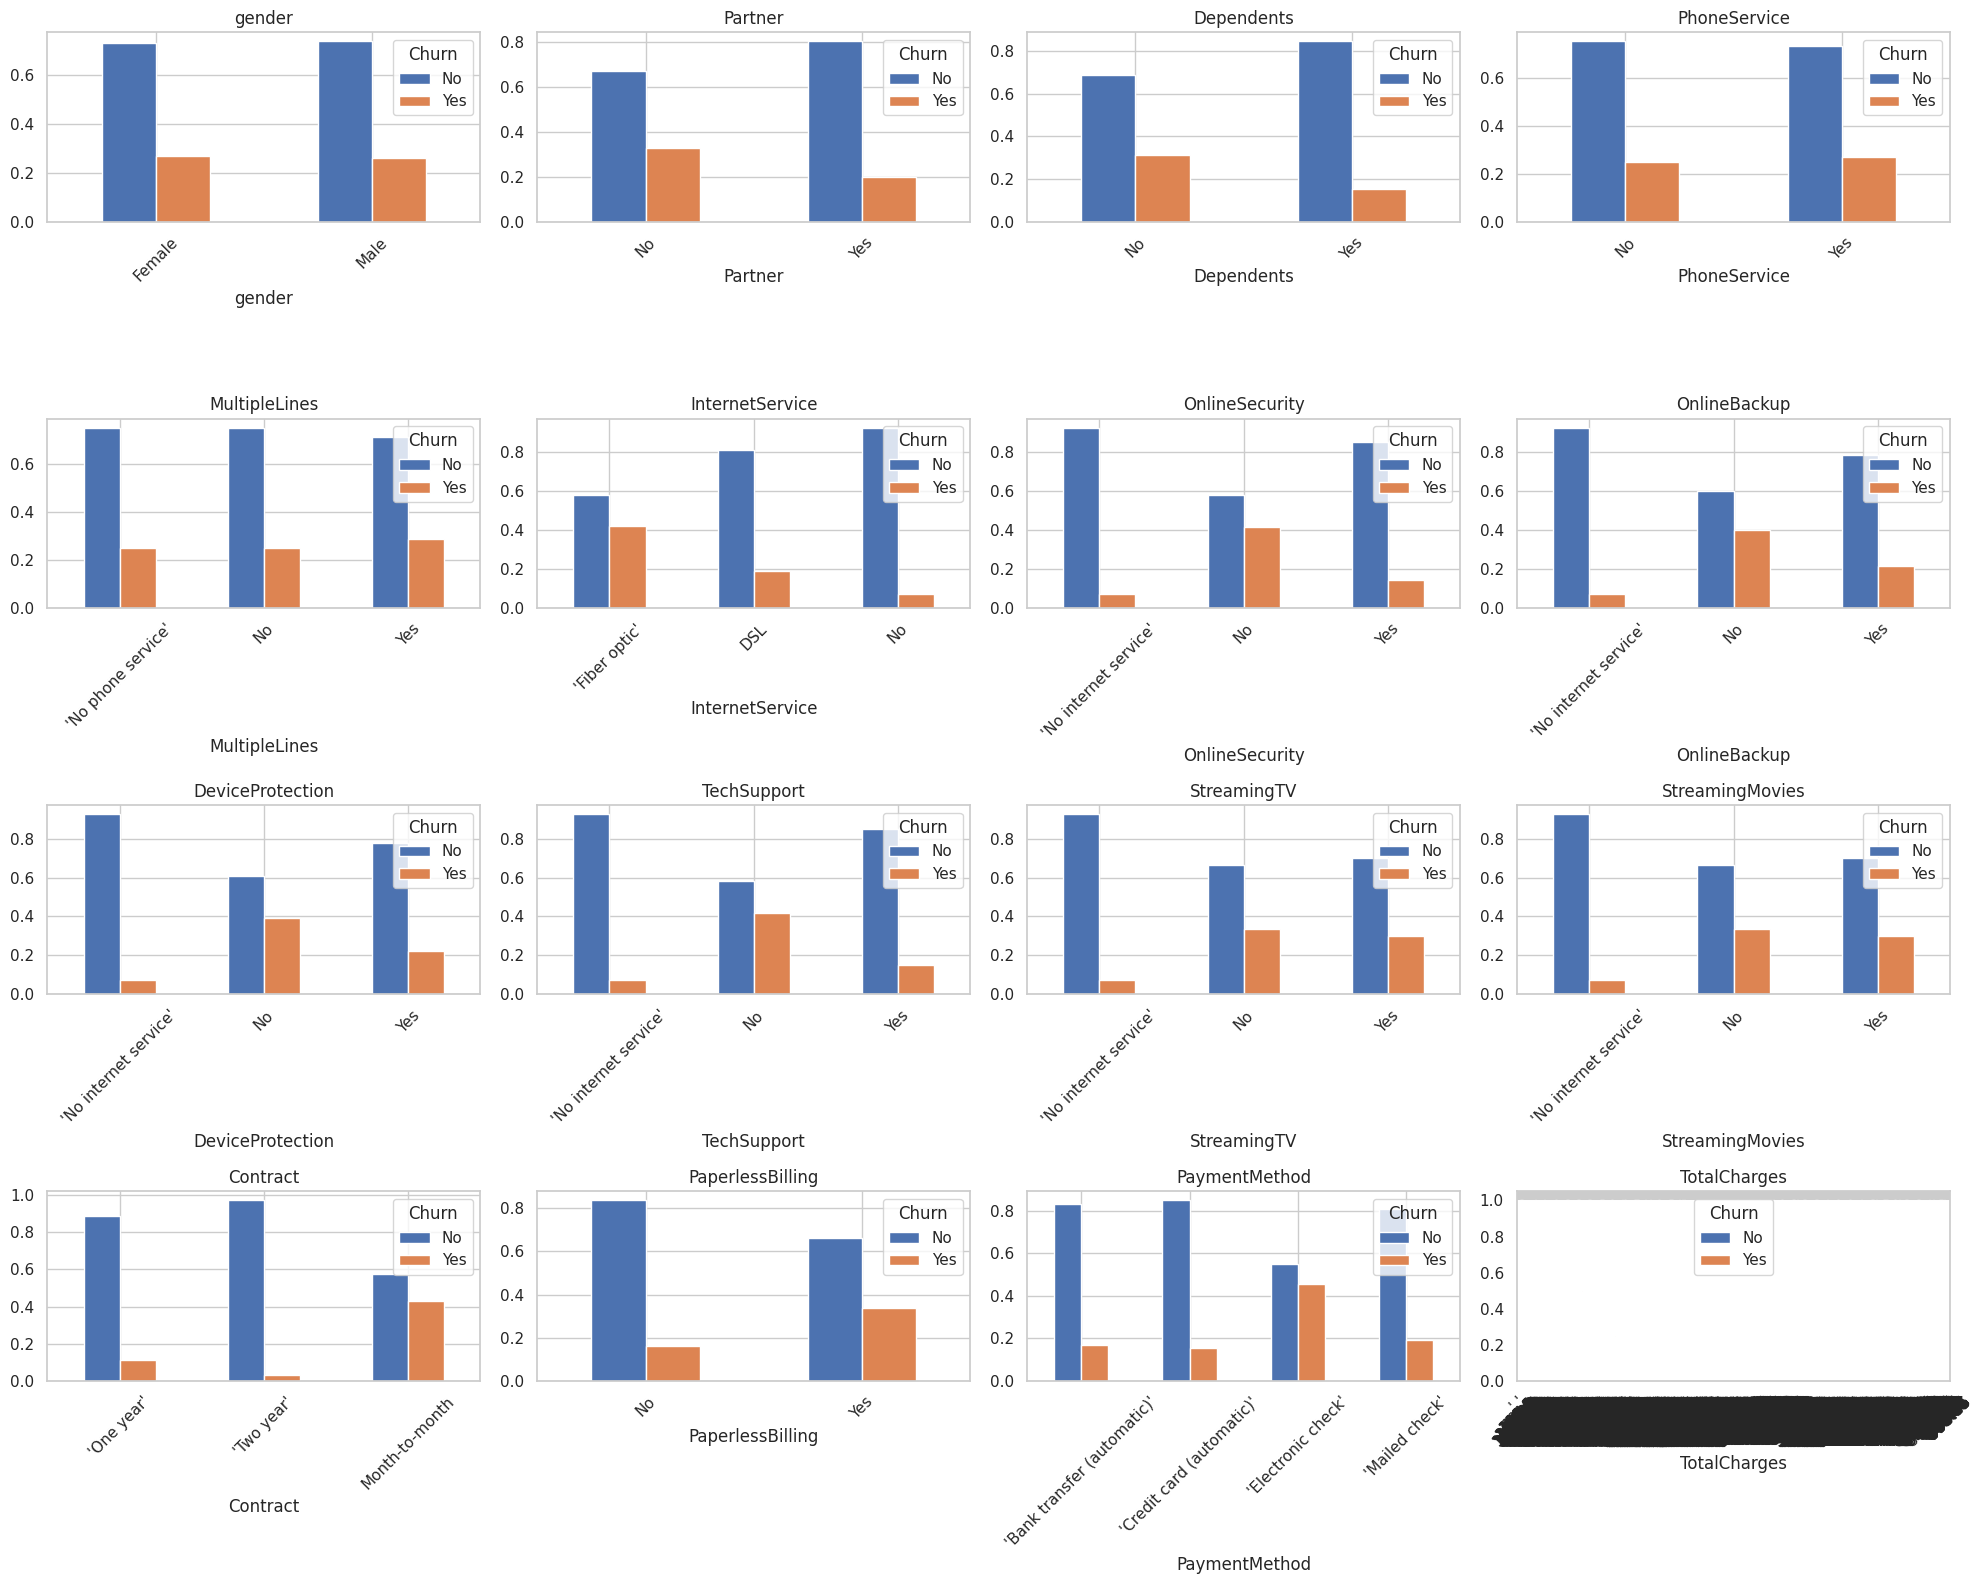

In [ ]:
# 类别特征与流失的关联
categorical_cols = df_raw.select_dtypes(include=["object"]).columns.drop(["customerID"], errors="ignore")

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
# 选择前16个类别特征进行可视化
for i, col in enumerate(categorical_cols[:16]):
    # 展示不同特征取值下的客户流失率。
    pd.crosstab(df_raw[col], df_raw["Churn"], normalize="index").plot(
        kind="bar", ax=axes[i], title=col, rot=45
    )

plt.tight_layout() # 调整子图间距
plt.show()

/tmp/ipykernel_295742/3813669834.py:12: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_295742/3813669834.py:12: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/zlzhangn/projects/ml-cases-practice/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zlzhangn/projects/ml-cases-practice/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


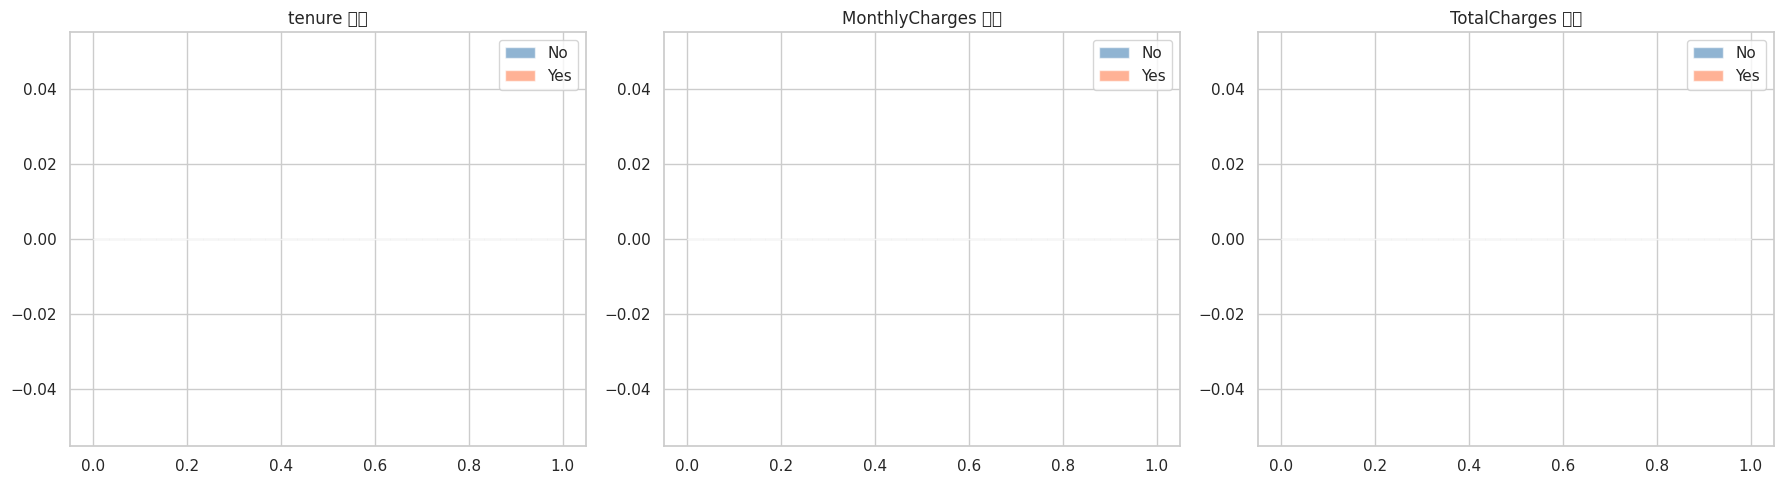

In [ ]:
# 数值特征分布
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    for churn, color in zip(["No", "Yes"], ["steelblue", "coral"]):
        subset = df_raw[df_raw["Churn"] == churn]
        axes[i].hist(subset[col].dropna(), bins=30, alpha=0.6, label=churn, color=color)
    axes[i].set_title(f"{col} 分布")
    axes[i].legend()

plt.tight_layout()
plt.show()

/home/zlzhangn/projects/ml-cases-practice/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zlzhangn/projects/ml-cases-practice/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zlzhangn/projects/ml-cases-practice/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zlzhangn/projects/ml-cases-practice/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zlzhangn/projects/ml-c

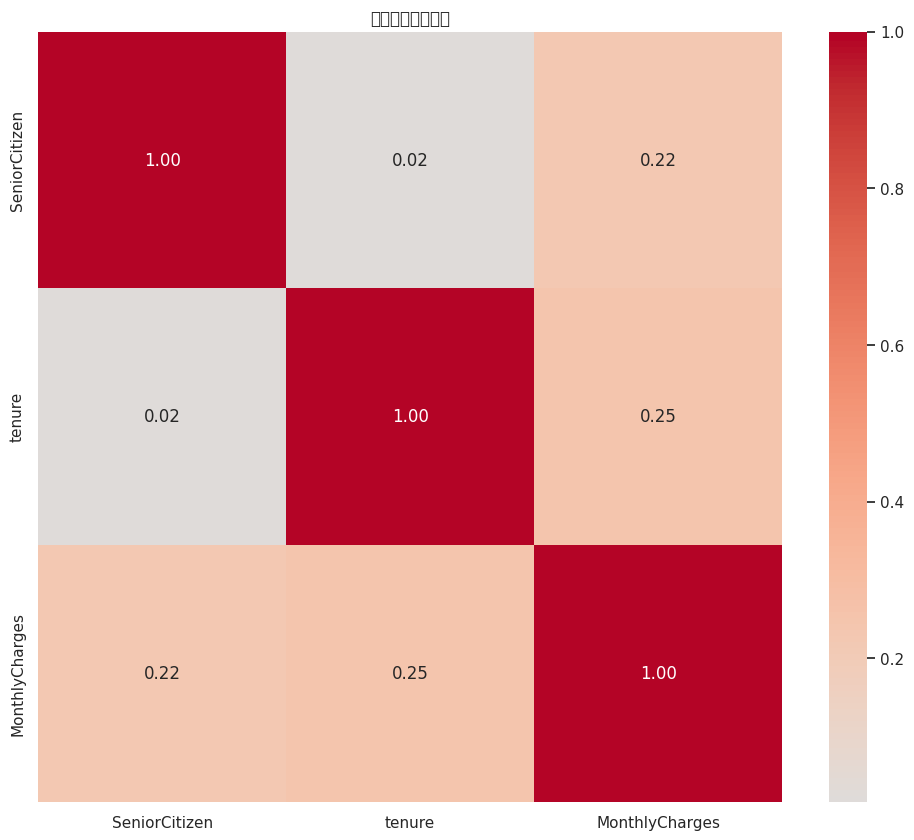

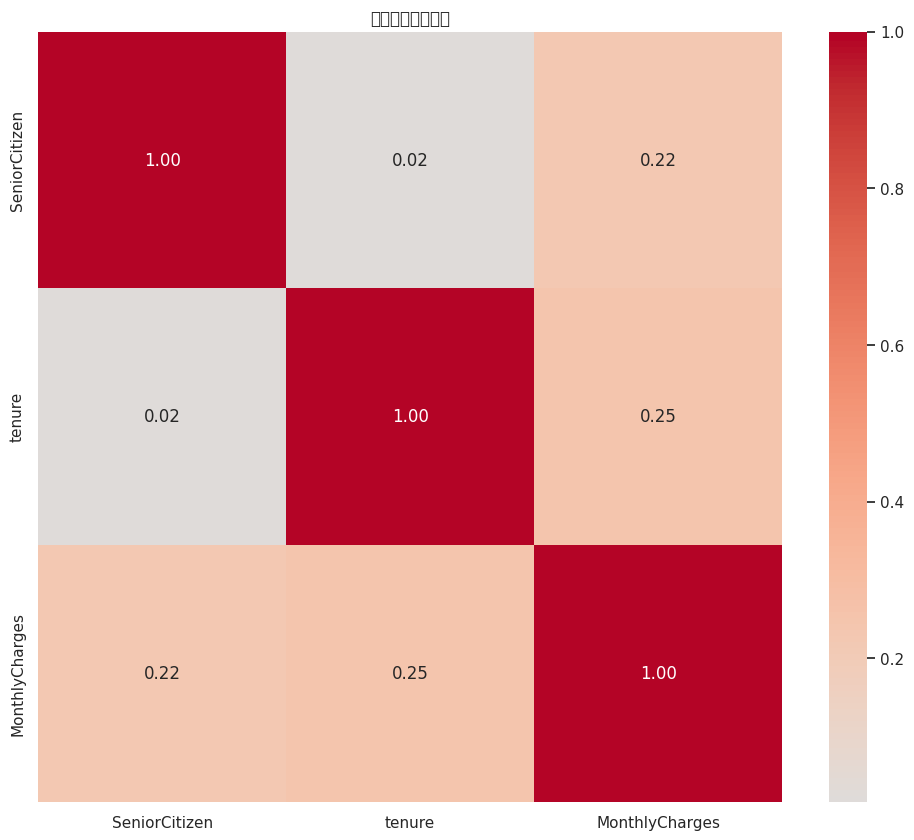

In [8]:
# 数值特征相关性
plot_corr_heatmap(df_raw.select_dtypes(include=["number"]))